In [1]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 277.9 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 1.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 1.2 MB/s eta 0:00:0000:0100:02m
Note: you may need to restart the kernel to use updated packages.


In [2]:
import shap

print(shap.__version__)

0.49.1


In [3]:
import joblib

xgb_model = joblib.load(
    "../models/credit_risk_model.pkl"
)

In [4]:
preprocessor = xgb_model.named_steps["preprocessor"]

classifier = xgb_model.named_steps["classifier"]

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

df_clean = pd.read_csv("../data/processed/train_cleaned.csv")

X = df_clean.drop("TARGET", axis=1)
y = df_clean["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
X_test_transformed = preprocessor.transform(X_test)

In [9]:
import xgboost
import shap

print("XGBoost:", xgboost.__version__)
print("SHAP:", shap.__version__)

XGBoost: 3.2.0
SHAP: 0.49.1


In [10]:
classifier = xgb_model.named_steps["classifier"]

print(type(classifier))

<class 'xgboost.sklearn.XGBClassifier'>


In [12]:
import pandas as pd

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": classifier.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
28,num__EXT_SOURCE_3,0.049522
27,num__EXT_SOURCE_2,0.045152
92,cat__NAME_EDUCATION_TYPE_Higher education,0.024283
86,cat__NAME_INCOME_TYPE_Pensioner,0.022472
69,cat__CODE_GENDER_F,0.021661
70,cat__CODE_GENDER_M,0.019985
90,cat__NAME_INCOME_TYPE_Working,0.015102
42,num__FLAG_DOCUMENT_3,0.014201
72,cat__FLAG_OWN_CAR_N,0.013508
5,num__AMT_GOODS_PRICE,0.011392


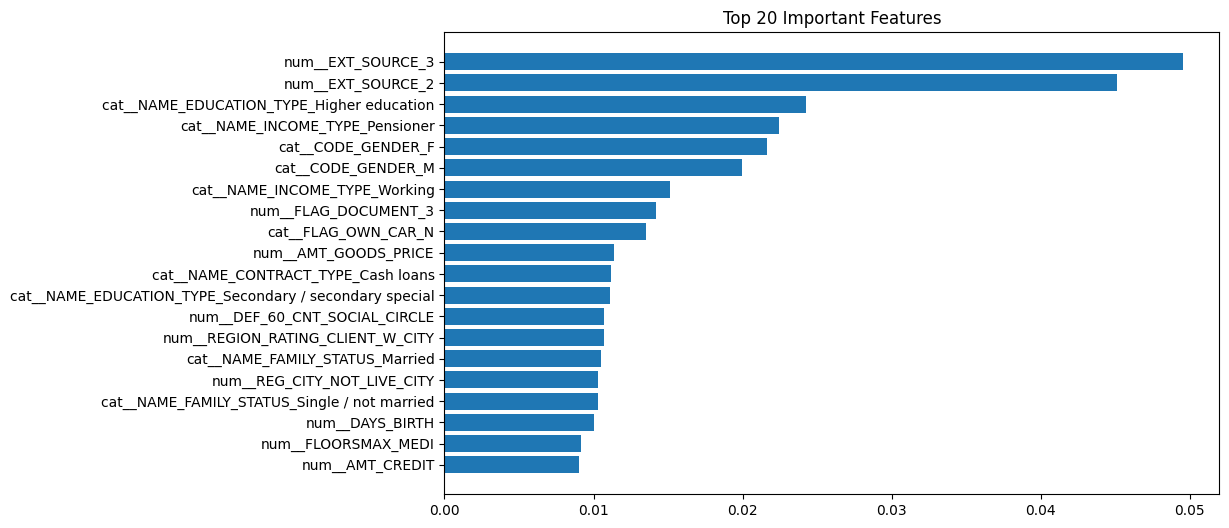

In [13]:
import matplotlib.pyplot as plt

top20 = importance_df.head(20)

plt.figure(figsize=(10,6))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features")
plt.show()

In [14]:
plt.savefig(
    "../documents/feature_importance.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

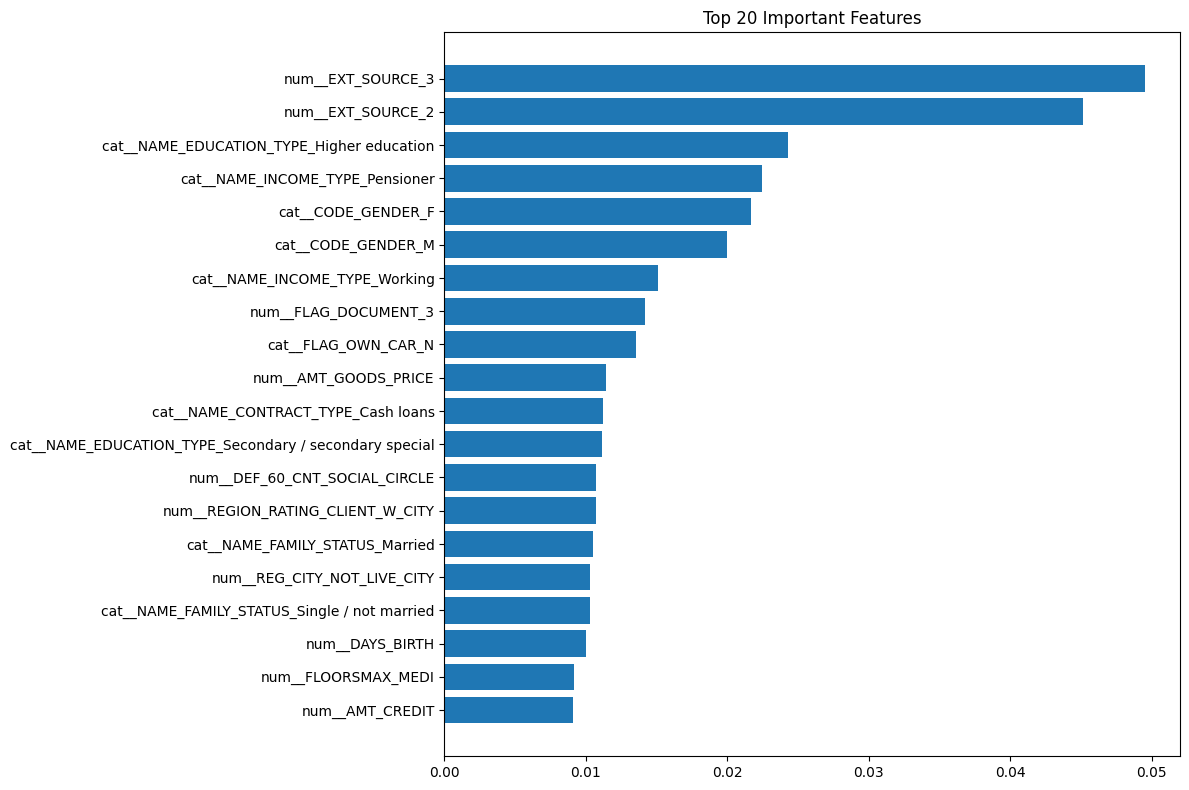

In [15]:
import matplotlib.pyplot as plt

top20 = importance_df.head(20)

plt.figure(figsize=(12,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.tight_layout()

plt.savefig(
    "../documents/feature_importance.png",
    bbox_inches="tight"
)

plt.show()